# **Deliverable 2: X-ray Imaging and Computed Tomography (CT)**

---

## Overview

This deliverable covers key concepts from **Lectures 13–18** (Weeks 6–7) of the course. You will explore:

- X-ray tube design and production
- Projection radiography geometry, contrast, and scatter reduction
- Digital X-ray detectors and image formation
- CT acquisition, reconstruction, image quality, and dose metrics
- Protocol design and optimization for clinical goals

You will engage with the material through conceptual questions, coding exercises, error analysis, and a design challenge. By the end of this deliverable, you will be able to analyze and simulate X-ray and CT imaging systems, interpret image quality trade-offs, optimize protocols, and apply quantitative reasoning to real-world clinical scenarios.

---

## Part 1: X-ray Production and Spectrum



### Key Concepts

- **X-ray Tube Physics:** X-rays are produced when high-speed electrons strike a metal target (anode), resulting in rapid deceleration (bremsstrahlung) and ejection of inner-shell electrons (characteristic X-rays). The output spectrum is a combination of continuous (bremsstrahlung) and discrete (characteristic) peaks.
- **Tube Voltage (kVp):** Sets the maximum photon energy; higher kVp increases beam penetration but reduces contrast.
- **Tube Current (mA):** Controls the number of electrons (and thus photons) produced per second; affects image brightness and patient dose.
- **Filtration:** Removes low-energy photons (which contribute to dose but not image quality), resulting in a "harder" (higher average energy) spectrum. The filtered spectrum $I(E)$ is zero for $E < E_{filter}$.
- **Anode Material:** Determines the energy of characteristic peaks (e.g., tungsten anode: 59 and 67 keV).


### 1.1 X-ray Tube Design Scenario

You are tasked with designing an X-ray tube for a pediatric chest radiography system. The goal is to minimize patient dose while maintaining diagnostic image quality.


### **Question 1**

- a)  Explain the roles of tube voltage (kVp) and tube current (mA) in shaping the X-ray spectrum and affecting patient dose.
- b) Describe how filtration and the choice of anode material influence the X-ray spectrum and image quality.
- c) Propose a set of tube parameters (kVp, mA, filtration) for pediatric imaging and justify your choices based on physical principles.


### **Coding Exercise 1**

1. Implement a function `simulate_xray_spectrum(kvp, e_filter)` that returns the energy (keV) and relative intensity arrays.
2. Plot the spectrum for kVp = 80, 100, 120 keV and E_filter = 30 keV.

a) Role of Tube Voltage (kVp) and Tube Current (mA)
Tube voltage (kVp) determines the kinetic energy of electrons striking the anode. Higher kVp results in higher energy photons and produces a harder, more penetrating beam. Increased penetration reduces differences in tissue attenuation, which lowers image contrast. While increasing kVp increases overall photon energy and beam output, less energy is deposited superficially in the skin due to improved penetration, although dose to deeper tissues may increase.
Tube current (mA) determines the number of electrons traveling from the cathode to the anode per second. Increasing mA increases the number of X-ray photons produced but does not change the maximum or average photon energy. Because more photons are generated, patient dose increases approximately proportionally with mAs. Higher mA also increases detector exposure and reduces quantum noise, resulting in a brighter image.

b) Effect of Filtration and Anode Material
Filtration removes low-energy photons from the X-ray beam by placing absorbing material (such as aluminum) in the beam path. Low-energy photons are more likely to be absorbed in the patient and contribute to dose without improving image quality. Removing them hardens the beam and improves efficiency. However, filtration also reduces total photon number, which may require adjustment of mAs to maintain adequate detector exposure.
The anode material influences the characteristic X-ray energies produced. When high-speed electrons eject inner-shell electrons from anode atoms, outer-shell electrons fill the vacancy and emit characteristic X-rays at element-specific energies. Tungsten is commonly used because its characteristic energies fall within the diagnostic range and it tolerates high heat loads. Different materials (such as molybdenum in mammography) produce characteristic X-rays in energy ranges better suited for specific imaging tasks, allowing optimization of image contrast.

c) Proposed Tube Parameters for Pediatric Imaging

-Lower kVp range (approximately 70–80 kVp): Pediatric patients have thinner chest walls and reduced tissue attenuation compared to adults, so lower photon energies are sufficient to achieve adequate penetration. Using a lower kVp also helps maintain better image contrast, particularly for differentiating soft tissue structures within the lungs.

-Lower mAs: Because children require fewer photons to produce an adequate image, mAs should be reduced compared to adult protocols. This minimizes radiation dose. However, mAs must not be reduced excessively, as too few photons reaching the detector will increase quantum noise and degrade image quality. A balance is required between dose reduction and maintaining sufficient signal-to-noise ratio.

-Aluminum filtration: Aluminum filtration removes low-energy photons that would primarily be absorbed superficially and contribute to patient dose without improving image formation. This hardens the beam and increases efficiency, which is particularly important in pediatric imaging due to increased radiosensitivity.

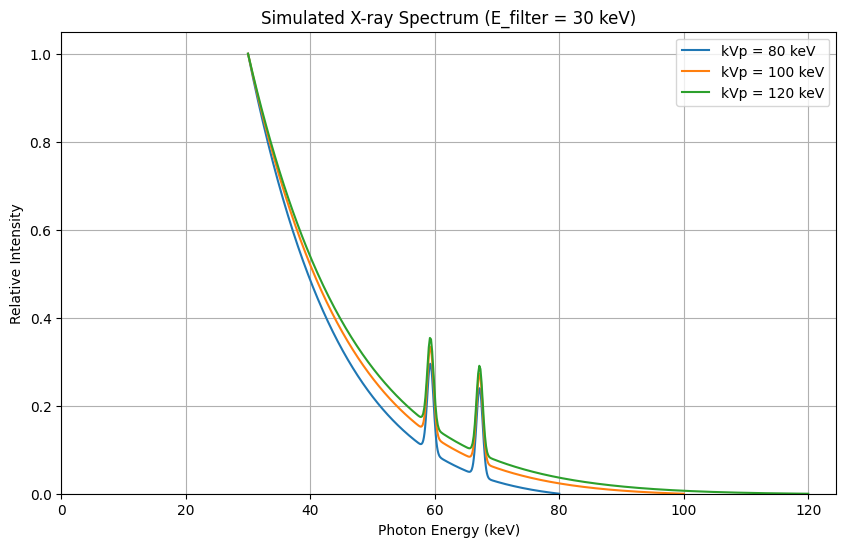

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_xray_spectrum(kvp, e_filter, num_points=500, anode_material='tungsten'):
    """
    Simulates a simplified X-ray spectrum.

    Args:
        kvp (float): Tube voltage in keV.
        e_filter (float): Energy of the filter in keV.
        num_points (int): Number of energy points for the spectrum.
        anode_material (str): Anode material (e.g., 'tungsten').

    Returns:
        tuple: (energy_array, intensity_array)
    """
    # Energy range from filter energy to kVp
    energy = np.linspace(e_filter, kvp, num_points)
    intensity = np.zeros_like(energy, dtype=float)

    # Bremsstrahlung component (simplified model: decreases linearly from peak to 0 at kVp)
    # Intensity is roughly proportional to Z * (kVp - E) / E for bremsstrahlung
    # Here we'll use a simpler approximation that peaks at lower energies and drops off
    bremsstrahlung_scaling = 1.0
    # Simple linear decrease, avoiding division by zero and making it non-zero at higher energies
    intensity_brem = bremsstrahlung_scaling * (kvp - energy) * np.exp(-energy/20) # Added exponential decay for more realistic shape
    intensity_brem[intensity_brem < 0] = 0 # Ensure no negative intensity
    intensity += intensity_brem

    # Characteristic X-rays (simplified: discrete peaks)
    characteristic_energies = {
        'tungsten': [59.3, 67.2] # K-alpha1 and K-beta1 for Tungsten
    }

    if anode_material in characteristic_energies:
        for char_e in characteristic_energies[anode_material]:
            # Add a characteristic peak if within the energy range and above filter
            if e_filter <= char_e <= kvp:
                # Find the closest index in the energy array
                idx = np.argmin(np.abs(energy - char_e))
                # Add a peak; using a Gaussian-like shape for visual representation
                sigma = 0.5 # width of the peak
                peak_intensity = 0.2 * np.max(intensity) # Relative intensity of characteristic peak
                intensity += peak_intensity * np.exp(-((energy - char_e)**2) / (2 * sigma**2))

    # Apply filtration (already handled by linspace starting from e_filter)
    # Ensure intensity is zero below e_filter (already implicit)
    intensity[energy < e_filter] = 0

    # Normalize intensity for better plotting comparison
    if np.max(intensity) > 0:
        intensity = intensity / np.max(intensity)

    return energy, intensity

# Plot the spectrum for kVp = 80, 100, 120 keV and E_filter = 30 keV
kvp_values = [80, 100, 120]
e_filter_value = 30 # keV

plt.figure(figsize=(10, 6))

for kvp in kvp_values:
    energy, intensity = simulate_xray_spectrum(kvp, e_filter_value)
    plt.plot(energy, intensity, label=f'kVp = {kvp} keV')

plt.title(f'Simulated X-ray Spectrum (E_filter = {e_filter_value} keV)')
plt.xlabel('Photon Energy (keV)')
plt.ylabel('Relative Intensity')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0) # Ensure y-axis starts at 0
plt.xlim(left=0) # Ensure x-axis starts at 0
plt.show()

# Analyze and discuss the results
# Discussion is provided in a separate markdown cell right below.

The plot illustrates the distribution of X-ray photon energies and their relative intensities at 80, 100, and 120 kVp. As kVp increases, two main effects are observed. First, the maximum photon energy increases because electrons strike the anode with greater kinetic energy. Second, overall X-ray output increases, resulting in higher photon intensity across the spectrum. The sharp peaks visible in the spectrum correspond to characteristic X-rays of tungsten, typically around 59 keV and 67 keV. These peaks occur when high-energy electrons eject inner-shell electrons from tungsten atoms, and outer-shell electrons transition to fill the vacancies. The energy difference between the shells is released as characteristic X-ray photons, producing distinct peaks at specific energies.

---

## Part 2: CT Simulation, Error Analysis & Design

### Key Concepts

- Shepp-Logan Phantom: A digital test object for CT simulation.
- Sinogram: 2D plot of projection data as a function of angle and position.
- Image Reconstruction: Filtered backprojection and iterative methods.
- Error Analysis: Identifying and quantifying sources of error/artifacts in CT reconstruction.
- Design & Optimization: Creating and optimizing CT protocols for specific clinical goals.


### 2.1 Shepp-Logan Phantom and Sinogram

### **Coding Exercise 2**

- a) Generate a Shepp-Logan digital phantom in Python (use `skimage.data.shepp_logan_phantom` or custom code).
- b) Simulate CT projections (sinogram) of the phantom using the Radon transform.
- c) Reconstruct the image from the sinogram using filtered backprojection.


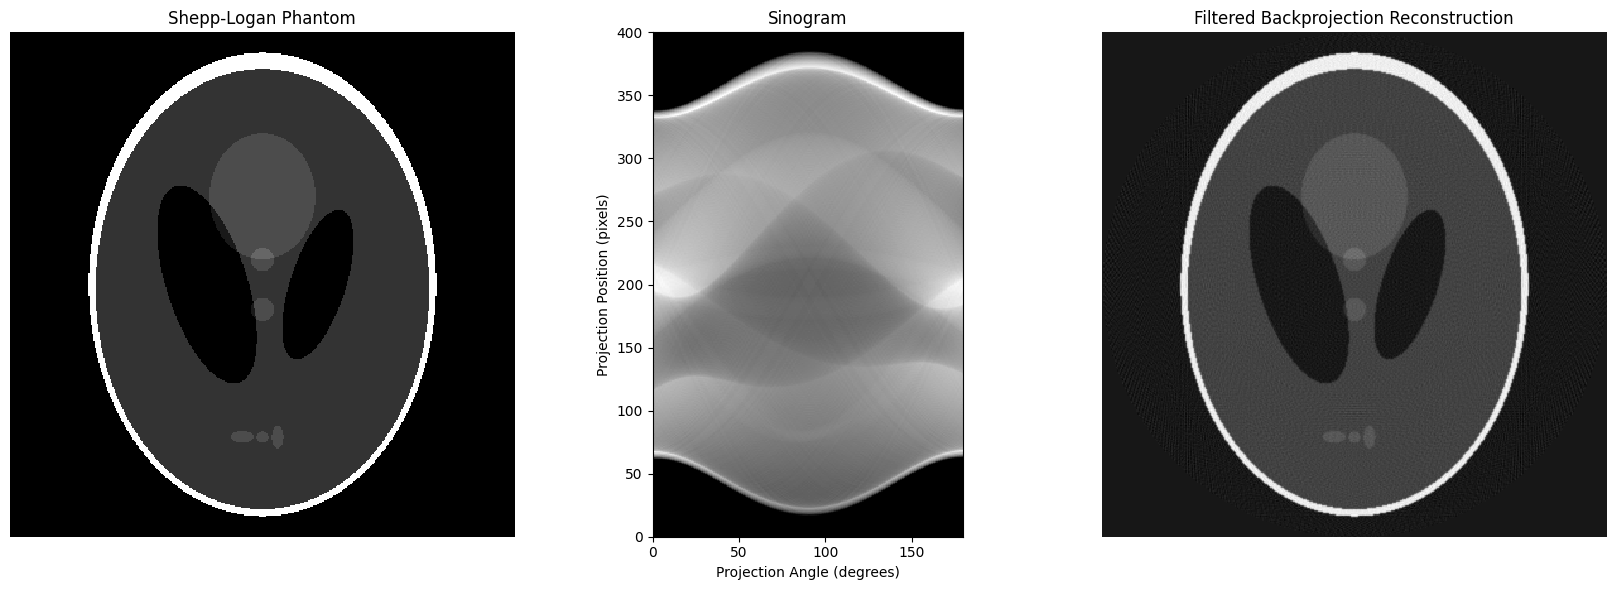

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import radon, iradon, resize

N = 400
theta = np.linspace(0, 180, 180, endpoint=False)

# a) Generate Shepp-Logan phantom
phantom = resize(shepp_logan_phantom(), (N, N), anti_aliasing=True)

# b) Generate sinogram
sinogram = radon(phantom, theta=theta, circle=True)

# c) Reconstruct using FBP
reconstruction = iradon(sinogram, theta=theta, filter_name="ramp", circle=True)

fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1.2, 0.55, 1.2])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

ax1.imshow(phantom, cmap="gray", interpolation="nearest")
ax1.set_title("Shepp-Logan Phantom")
ax1.axis("off")

ax2.imshow(
    sinogram,
    cmap="gray",
    aspect="auto",
    interpolation="nearest",
    origin="lower",
    extent=[0, 180, 0, N]
)
ax2.set_xlim(0, 180)
ax2.set_ylim(0, N)
ax2.set_title("Sinogram")
ax2.set_xlabel("Projection Angle (degrees)")
ax2.set_ylabel("Projection Position (pixels)")

ax3.imshow(reconstruction, cmap="gray", interpolation="nearest")
ax3.set_title("Filtered Backprojection Reconstruction")
ax3.axis("off")

plt.tight_layout()
plt.show()


### 2.2 Error Analysis


### **Question 2**

- a) Identify and describe at least one source of error or artifact in your reconstructed image (e.g., limited projections, noise, motion, beam hardening).
- b) Quantify the impact of one error (e.g., measure reconstruction error as projections are reduced or noise is increased).
- c) Propose and implement a method to mitigate one artifact or error, and evaluate its effectiveness.


### **Coding Exercise 3**

Implement your method to mitigate an artifact or error and evaluate its effectiveness.

a) Identify and describe at least one source of error or artifact in your reconstructed image

In the filtered backprojection (FBP) reconstruction, a noticeable source of error is the presence of mild streaking and slight blurring around sharp boundaries in the phantom. This occurs because the sinogram is generated using a finite number of discrete projection angles rather than a continuous set of views, so the reconstruction is limited by angular sampling. In addition, the ramp filter used in FBP emphasizes high-frequency information to sharpen edges, but this also makes the reconstruction more sensitive to sampling limitations and any noise, which can appear as streaks or graininess in the final image.

b) Quantify the impact of one error

The impact of limited projections can be quantified by reducing the number of projection angles and measuring how reconstruction accuracy changes. A common metric is the root mean squared error (RMSE) between the reconstructed image and the original Shepp–Logan phantom (ground truth). As the number of projections decreases (for example from 180 down to 30), RMSE typically increases and visual artifacts become more obvious. This confirms that fewer projections reduce the amount of information available for reconstruction, leading to greater error and more pronounced streaking.

c) Propose and implement a method to mitigate one artifact or error, and evaluate its effectiveness

To mitigate the grainy and streaky appearance caused by high-frequency noise amplification in FBP, a Gaussian low-pass filter can be applied. Instead of filtering the reconstructed image directly, a more stable approach is to apply the Gaussian filter to the sinogram before reconstruction. This reduces high-frequency noise in the projection data before the ramp filter and backprojection steps amplify it. Effectiveness is evaluated by comparing RMSE before and after mitigation and visually inspecting whether noise/streaking is reduced, while noting any loss of edge sharpness due to smoothing.

RMSE before mitigation: 0.0343
RMSE after sinogram Gaussian (sigma=1.0): 0.0553


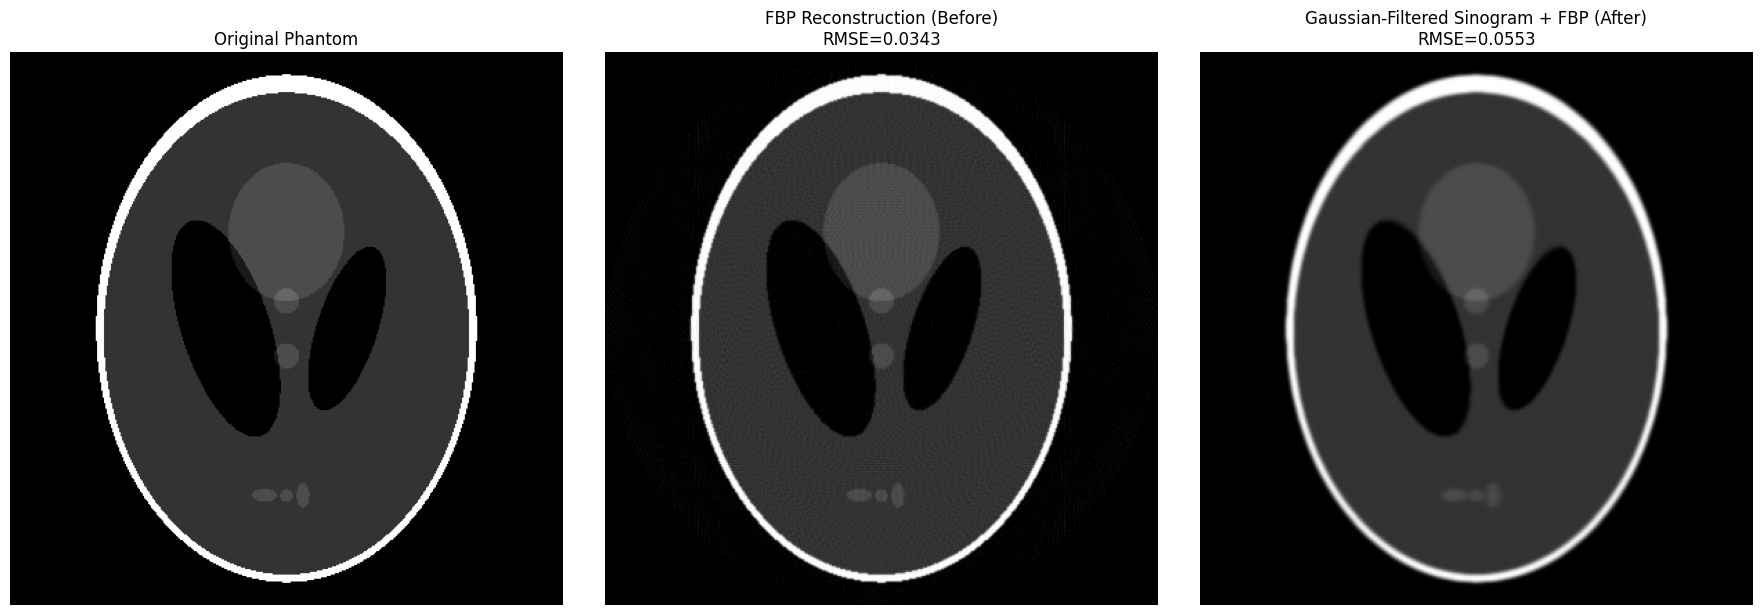

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import iradon
from skimage.filters import gaussian
from skimage.metrics import mean_squared_error

sigma = 1.0

sinogram_gauss = gaussian(sinogram, sigma=sigma, preserve_range=True)

recon_before = reconstruction
recon_after = iradon(sinogram_gauss, theta=theta, filter_name="ramp", circle=True)

rmse_before = np.sqrt(mean_squared_error(phantom, recon_before))
rmse_after = np.sqrt(mean_squared_error(phantom, recon_after))

print(f"RMSE before mitigation: {rmse_before:.4f}")
print(f"RMSE after sinogram Gaussian (sigma={sigma}): {rmse_after:.4f}")

vmin, vmax = np.min(phantom), np.max(phantom)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(phantom, cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title("Original Phantom")
axes[0].axis("off")

axes[1].imshow(recon_before, cmap="gray", vmin=vmin, vmax=vmax)
axes[1].set_title(f"FBP Reconstruction (Before)\nRMSE={rmse_before:.4f}")
axes[1].axis("off")

axes[2].imshow(recon_after, cmap="gray", vmin=vmin, vmax=vmax)
axes[2].set_title(f"Gaussian-Filtered Sinogram + FBP (After)\nRMSE={rmse_after:.4f}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

Applying a Gaussian filter to the sinogram reduces high-frequency noise before filtered backprojection, resulting in a smoother reconstruction with less visible graininess and streaking. Visually, the image appears more uniform and less noisy compared to the original FBP result. However, because Gaussian filtering suppresses high-frequency components, it can also blur sharp edges and fine structural details. If RMSE decreases after filtering, this indicates improved overall agreement with the ground truth; if it increases, it suggests that smoothing introduced additional deviation despite improved visual appearance. Overall, the method effectively reduces noise but highlights the tradeoff in CT reconstruction between noise suppression and preservation of spatial resolution.

### 2.3 CT Protocol Design & Optimization


### **Question 3**

- a) Choose a clinical goal (e.g., maximize nodule detectability, minimize dose).
- b) Optimize acquisition parameters (number of projections, rotation angles, detector size, noise level) to achieve your goal.
- c) Justify your design choices based on physical principles and clinical needs.
- d) Reflect on the trade-offs and limitations of your design.


a) Clinical goal
The selected clinical goal is to minimize radiation dose while maintaining sufficient image quality for reliable visualization of anatomical structures. The aim is to reduce exposure without significantly increasing reconstruction error or introducing severe artifacts.

b) Optimized acquisition parameters

- Number of projections:reduce from 180 to approximately 90–120 projections to lower total sampling (and simulated dose) while maintaining acceptable reconstruction stability.

- Rotation angle range: use 0–180 degrees, which is sufficient for parallel-beam CT reconstruction and avoids unnecessary redundant sampling.
Detector size (image matrix N): choose a moderate size such as N = 256–400 to preserve spatial detail without excessive computational cost or increased sensitivity to noise.

- Noise level: maintain a reasonable exposure level to control quantum noise; if operating at lower sampling, apply mild Gaussian filtering to suppress high-frequency noise amplification.

c) Justification based on physical principles and clinical needs
Reducing the number of projections lowers total acquisition and therefore dose, but too few projections lead to angular undersampling and visible streak artifacts. A range of 90–120 projections provides a balance between dose reduction and reconstruction accuracy. A 0–180 degree rotation is physically sufficient in parallel-beam geometry because it contains all required projection information. Detector resolution determines spatial sampling; moderate resolution preserves clinically relevant detail without oversampling. Since filtered backprojection amplifies high-frequency components, mild smoothing can help control noise when dose or projections are reduced.

d) Trade-offs and limitations
The main trade-off is between dose and image quality. Reducing projections decreases exposure but increases streaking and reconstruction error. Applying Gaussian filtering reduces visible noise but introduces edge blurring and reduced spatial resolution. Additionally, this simulation assumes idealized conditions and does not account for scatter, beam hardening, or motion, so real clinical optimization would require further adjustments.

---

## Part 3: Projection Radiography & Image Quality



### Key Concepts

- **Scatter:** Primarily due to Compton interactions; scattered photons degrade image contrast by adding unwanted background signal. Scatter increases with patient thickness and field size. (See Lecture 14)
- **Geometric Unsharpness ($U_g$):** Caused by the finite size of the X-ray source.
- **Contrast Degradation:** The scatter-to-primary ratio (SPR) quantifies the amount of scatter relative to primary photons. Higher SPR means lower contrast. Contrast degradation factor:

$$C_{degraded} = \frac{C_{ideal}}{1 + SPR}$$
- **Scatter Reduction:** Use of grids, air gaps, or collimation can reduce scatter but may increase dose or reduce signal.


### 3.1 Scatter and Contrast


### **Questions 4**

- a) Explain the physical origin of scatter in projection radiography and its impact on image contrast.
- b) Describe two methods to reduce scatter and discuss their trade-offs.
- c) Calculate the contrast degradation factor if the scatter-to-primary ratio (SPR) is 1.5. What percent of the original contrast remains?


### **Coding Exercise 4**

1. Implement `geometric_unsharpness(f, a, b)`.
2. Plot $U_g$ as a function of $b$ for $f=1$ mm, $a=100$ cm, and $b$ from 0 to 20 cm.

In [ ]:
# TODO: Implement geometric_unsharpness(f, a, b)
# def geometric_unsharpness(f, a, b):
#     ...

# TODO: Plot U_g as a function of b
# ...

### 3.2 Quantitative Comparison of Scatter Reduction Techniques


### **Questions 5**

- a) For each technique, calculate the percent contrast improvement using the contrast degradation formula.
- b) Summarize your findings: Which technique is most effective? What are the trade-offs (e.g., dose, practicality, image artifacts)?

### 3.3 Simulating Scatter Effects and Grid Optimization

### **Coding Exercise 5**

In this exercise, you will simulate the effect of scatter on a simple X-ray image and explore how grid design can optimize image contrast.

**Scenario:**
You are given a 1D 'image' (e.g., a step function representing an object) and must model the effect of scatter as an additive background proportional to the primary signal. You will then simulate the use of an anti-scatter grid with variable grid ratio to reduce scatter, and determine the optimal grid ratio for maximizing contrast while considering signal loss.

**Tasks:**
1. Simulate the effect of scatter on a simple 1D object (e.g., a step function) by adding a scatter component proportional to the primary signal using the fixed SPR value.
2. Model the impact of an anti-scatter grid: for each grid ratio $G$, reduce scatter by $1/(1+G)$ and primary signal by $T_p$ (e.g., $T_p = 1 - 0.02 \times G$).
3. Plot image contrast as a function of grid ratio for the fixed SPR, and identify the grid ratio that maximizes contrast.

**Hints:**
- Use matplotlib for plotting.
- You may assume a fixed SPR value (e.g., SPR = 1.5).
- You may define contrast as $(I_{max} - I_{min})/(I_{max} + I_{min})$ for the detected signal.
- You may use a simple linear model for $T_p(G)$, e.g., $T_p = 1 - 0.02 	imes G$ (for $G$ from 0 to 12).

In [ ]:
# TODO: Simulate scatter and grid optimization for a 1D image
# ...

# TODO: Plot and analyze the effect of grid ratio on contrast
# ...

# TODO: Discuss your findings and trade-offs
# ...

---

## Part 4: X-ray Detectors & Quantum Efficiency



### Key Concepts

- **Quantum Efficiency (QE):** The fraction of incident X-ray photons detected and converted to signal. Higher QE improves SNR and allows for lower patient dose.

$$QE = \frac{\text{Detected photons}}{\text{Incident photons}}$$
- **Detective Quantum Efficiency (DQE):** Describes how well a detector preserves SNR across spatial frequencies.

$$DQE(f) = \frac{(SNR_{out}(f))^2}{(SNR_{in}(f))^2}$$
- **Readout Noise:** Electronic noise added during signal readout; becomes significant at low doses or for low-signal regions.
- **Detector Types:** Indirect (scintillator + photodiode) and direct (photoconductor) detectors have different QE and noise characteristics.


### 4.1 Detector Selection Scenario

### **Questions 6**

You are comparing two digital X-ray detectors for a trauma imaging suite:

   1.  Detector A: High quantum efficiency (QE), moderate readout noise
   2. Detector B: Lower QE, but very low readout noise

- a) Define quantum efficiency and explain its importance for image quality and dose.
- b) Discuss the trade-offs between quantum efficiency and readout noise for low-dose imaging.
- c) Which detector would you recommend for pediatric trauma imaging and why?


### **Coding Exercise 6**

1. Modify the code to add a third detector (Detector C) with your own parameters for SNR_out_C.
2. Plot and compare the DQE for all three detectors.
3. Briefly discuss how your changes affect the DQE curves.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compute_dqe(snr_in, snr_out):
    return (snr_out ** 2) / (snr_in ** 2)

# Example data for two detectors
spatial_freq = np.linspace(0, 5, 50)  # cycles/mm
snr_in = 100 * np.exp(-0.2 * spatial_freq)
snr_out_A = 80 * np.exp(-0.4 * spatial_freq)  # High QE, moderate noise
snr_out_B = 60 * np.exp(-0.25 * spatial_freq)  # Lower QE, low noise

dqe_A = compute_dqe(snr_in, snr_out_A)
dqe_B = compute_dqe(snr_in, snr_out_B)

plt.figure(figsize=(7,4))
plt.plot(spatial_freq, dqe_A, label='Detector A (High QE)')
plt.plot(spatial_freq, dqe_B, label='Detector B (Low Noise)')
plt.xlabel('Spatial Frequency (cycles/mm)')
plt.ylabel('DQE')
plt.title('Detective Quantum Efficiency vs. Spatial Frequency')
plt.legend()
plt.grid(True)
plt.show()

# TODO: Briefly discuss how your changes affect the DQE curves.

### **Coding Exercise 7**

1. Display the original image.
2. Apply contrast enhancement.
3. Apply brightness adjustment.
4. Display the adjusted images side-by-side.
5. Discuss how these changes affect image quality and visibility of features.

In [ ]:
#USE IMAGE 'Xray_Chest.png'

# TODO: Apply contrast enhancement
# ...

# TODO: Apply brightness adjustment
# ...

# TODO: Display the original and adjusted images
# ...

# TODO: Discuss the effects below

---

## Part 5: Computed Tomography (CT) Principles & Image Reconstruction



### Key Concepts

- **Hounsfield Units (HU):** Quantifies tissue attenuation relative to water.

$$HU = 1000 \cdot \frac{\mu_{tissue} - \mu_{water}}{\mu_{water}}$$
- **CT Projections:** Each projection is a line integral of attenuation coefficients along a path through the object:

$$P(\theta, t) = \int \mu(x, y) ds$$
- **Sinogram:** A 2D plot of projection data as a function of angle and position; each point in the object traces a sinusoidal path in the sinogram.
- **Image Reconstruction:** Filtered backprojection and iterative methods reconstruct the 2D image from projections.


### 5.1 Hounsfield Units and Tissue Contrast


### **Questions 7**

- a)  Define the Hounsfield unit and explain how it is calculated from measured attenuation coefficients.
- b) Calculate the HU for a tissue with:

$$
\mu_{\text{tissue}} = 0.22\ \text{cm}^{-1}, \quad
\mu_{\text{water}} = 0.20\ \text{cm}^{-1}, \quad
\mu_{\text{air}} = 0.0002\ \text{cm}^{-1}
$$

Show your calculation step by step.

- c) Discuss the clinical significance of HU values in CT imaging.


### **Coding Exercise 8**

1. Create a 2D numpy array representing a phantom with a circular region of higher attenuation.
2. Simulate the projection (sum of attenuation) at a given angle.
3. Plot the phantom and its projection profile.

In [ ]:
# TODO: Create a 2D numpy array phantom with a circular region
# ...

# TODO: Simulate the projection (sum of attenuation) at a given angle
# ...

# TODO: Plot the phantom and its projection profile
# ...

---

## Part 6: CT Image Quality, Artifacts, and Dose Optimization



### Key Concepts

- **Streak Artifacts:** Appear as bright/dark lines, often caused by high-attenuation objects (metal), beam hardening (lower energy photons absorbed more), or photon starvation (very low signal).
- **Noise:** In CT, noise is primarily quantum (photon) noise and is inversely proportional to the square root of dose:

$$\sigma = \frac{K}{\sqrt{D}}$$
- **Dose Optimization:** The goal is to minimize patient dose while maintaining diagnostic image quality. Techniques include automatic exposure control and iterative reconstruction.


### 6.1 CT Streak Artifact Analysis

### **Questions 8**

- a) Carefully examine the artifact in the image. Describe the physical and mathematical causes of streak artifacts in CT (reference concepts such as beam hardening, photon starvation, and reconstruction errors).
- b) Propose and explain at least two algorithmic or acquisition-based strategies to reduce or mitigate streak artifacts in clinical CT.


### **Coding Exercise 9**

1. Write a function `ct_noise_vs_dose(D, K)`.
2. Plot image noise as a function of dose for $K=10$ and $D$ from 1 to 100 (arbitrary units).

In [ ]:
# USE IMAGE 'Brain_CT.png'

# TODO: Write a function ct_noise_vs_dose(D, K)
# def ct_noise_vs_dose(D, K):
#     ...

# TODO: Plot image noise as a function of dose
# ...

# TODO: Analyze and discuss the results
# ...

---

## Part 7: Quantitative Analysis of CT Image Quality

### Key Concepts

- **SNR (Signal-to-Noise Ratio):**

$$\mathrm{SNR} = \frac{\mu_{signal}}{\sigma_{noise}}$$
- **RMSE (Root Mean Square Error):** Measures the average difference between two images:

$$RMSE = \sqrt{\frac{1}{N} \sum_{i=1}^N (I_i - I_{ref,i})^2}$$
- **Filtering:** Denoising filters (Gaussian, median, bilateral) can reduce noise but may blur edges or reduce detail.


### 7.1 SNR and RMSE Analysis


### **Coding Exercise 10**

1. Apply a denoising or edge-preserving filter of your choice (e.g., Gaussian, median, or bilateral filter).
2. Compute and compare the following metrics before and after filtering:
   - Signal-to-Noise Ratio (SNR)
   - Root Mean Square Error (RMSE)
   (You may use the original image as reference for RMSE, or compare to a region of interest.)
3. Discuss what these metrics reveal about image quality and the impact of filtering.

In [ ]:
# USE IMAGE 'Brain_CT.png'

# TODO: Apply a filter to img (e.g., Gaussian, median, etc.)
# filtered_img = ...

# TODO: Compute SNR and RMSE before and after filtering
# snr_before = ...
# snr_after = ...
# rmse = ...

# TODO: Visualize the original and filtered images
# ...

---

## **<u>Submission Requirements</u>**

**You must submit TWO files to D2L:**

1. **Jupyter Notebook** (`.ipynb`): Your completed notebook with all code, outputs, and written analysis. All cells must be executed in order.

2. **PDF Export** (`.pdf`): Export your notebook to PDF (File → Export as PDF, or print to PDF). Verify all figures and equations render correctly.

**Important:** All answers must be completed directly in this Jupyter notebook.

**File naming convention:** `LastName_FirstName_Deliverable2.ipynb` and `.pdf`

**Due:** Monday, March 2, 2026 at 11:59 PM

---

## Submission Summary

| Section | Questions/Analysis Due |
|---------|------------------------|
| **Part 1: X-ray Production & Spectrum** | Q1 (a,b,c), Coding Exercise 1 |
| **Part 2: CT Simulation, Error Analysis & Design** | Coding Exercise 2, Q2 (a,b,c), Coding Exercise 3, Q3 (a,b,c,d)  |
| **Part 3: Projection Radiography & Image Quality** | Q4 (a,b,c), Coding Exercise 4, Q5 (a,b), Coding Exercise 5 |
| **Part 4: X-ray Detectors & Quantum Efficiency** | Q6 (a,b,c), Coding Exercise 6, Coding Exercise 7|
| **Part 5: CT Principles & Image Reconstruction** | Q7 (a,b,c), Coding Exercise 8|
| **Part 6: CT Image Quality, Artifacts & Dose Optimization** | Q8 (a,b), Coding Exercise 9 |
| **Part 7: Quantitative Analysis of CT Image Quality** | Coding Exercise 10 |
